# HMM-DNN Based Automatic Speech Recognition

## Speech Processing Assignment

### STEP 1 - Objective

This project implements a Hybrid Automatic Speech Recognition (ASR) system using Deep Neural Networks combined with Hidden Markov Models.

The system pipeline includes:

- Speech preprocessing
- MFCC and Log-Mel feature extraction
- Deep Neural Network based acoustic modeling
- HMM based sequence modeling
- Viterbi decoding
- Word Error Rate evaluation


Dataset Used:

LibriSpeech ASR Corpus (test-clean subset)

In [1]:
## STEP2 - Import Required Libraries

# Core libraries

import os
import numpy as np
import matplotlib.pyplot as plt


# Deep Learning

import torch
import torch.nn as nn
import torchaudio


# Audio processing

import torchaudio.transforms as T


print("Torch Version:", torch.__version__)
print("TorchAudio Version:", torchaudio.__version__)

Torch Version: 2.4.0+cpu
TorchAudio Version: 2.4.0+cpu


In [3]:
## STEP 03 - Download/Load DataSet
# Create data directory
os.makedirs("./data", exist_ok=True)
# Download LibriSpeech test-clean subset
dataset = torchaudio.datasets.LIBRISPEECH(
root="./data",
url="test-clean",
download=True
)
print("Total audio samples:", len(dataset))

Total audio samples: 2620


In [4]:
## STEP 04 - Read One Speech Sample
waveform, sample_rate, transcript, speaker_id, chapter_id, utterance_id = dataset[0]
print("Sample Rate:", sample_rate)
print("\nTranscript:")
print(transcript)
print("\nWaveform Shape:")
print(waveform.shape)

Sample Rate: 16000

Transcript:
HE HOPED THERE WOULD BE STEW FOR DINNER TURNIPS AND CARROTS AND BRUISED POTATOES AND FAT MUTTON PIECES TO BE LADLED OUT IN THICK PEPPERED FLOUR FATTENED SAUCE

Waveform Shape:
torch.Size([1, 166960])


In [5]:
## STEP 05 - Play Audio Sample
from IPython.display import Audio
Audio(
waveform.numpy(),
rate=sample_rate
)

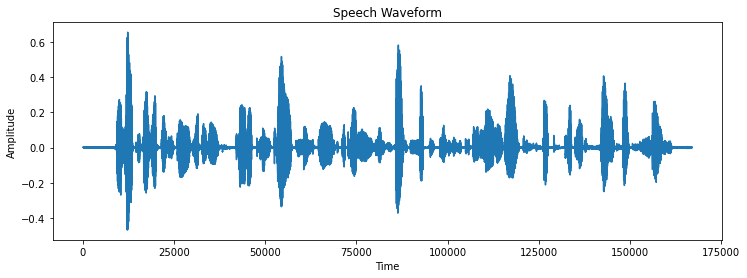

In [6]:
## STEP 06 - Visualize the Waveform
plt.figure(figsize=(12,4))
plt.plot(waveform.t().numpy())
plt.title("Speech Waveform")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

In [7]:
## STEP 7.1 Normalize the Waveform/Speech Signal
# Convert waveform to mono signal
speech_signal = waveform.squeeze()
print("Original Signal Shape:")
print(speech_signal.shape)
# Normalize amplitude
normalized_signal = speech_signal / torch.max(torch.abs(speech_signal))
print("\nNormalized Signal Range:")
print(
normalized_signal.min().item(),
normalized_signal.max().item()
)

Original Signal Shape:
torch.Size([166960])

Normalized Signal Range:
-0.7148194909095764 1.0


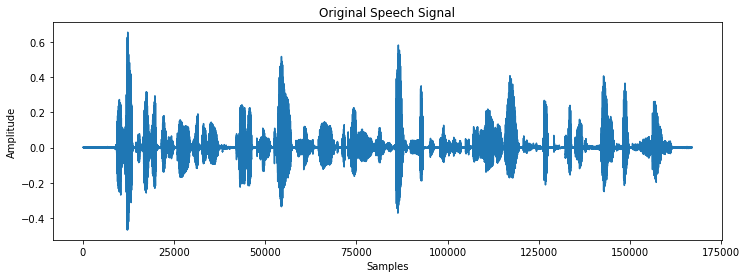

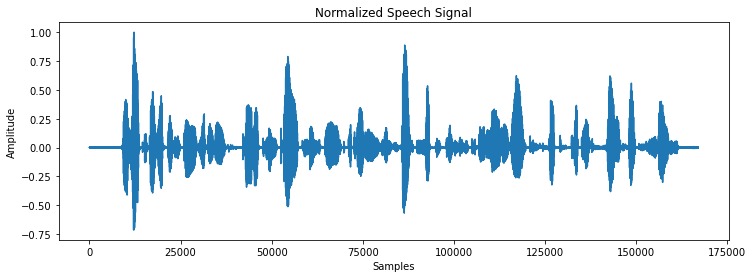

In [8]:
## STEP 7.2 Visualize Before and After Normalization
plt.figure(figsize=(12,4))
plt.plot(
speech_signal.numpy(),
label="Original"
)
plt.title("Original Speech Signal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()
plt.figure(figsize=(12,4))
plt.plot(
normalized_signal.numpy(),
label="Normalized"
)
plt.title("Normalized Speech Signal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

In [9]:
## STEP 7.3 Speech Framing
frame_length = int(0.025 * sample_rate)
hop_length = int(0.010 * sample_rate)
print("Frame Length:", frame_length)
print("Hop Length:", hop_length)
## Now Create Frames
frames = normalized_signal.unfold(
dimension=0,
size=frame_length,
step=hop_length
)
print("Frames Shape:")
print(frames.shape)

Frame Length: 400
Hop Length: 160
Frames Shape:
torch.Size([1042, 400])


In [10]:
## STEP 7.4 - Apply Hanning Window to Each Frame
hamming_window = torch.hann_window(frame_length)
windowed_frames = frames * hamming_window
print("Windowed Frames Shape:", windowed_frames.shape)

Windowed Frames Shape: torch.Size([1042, 400])


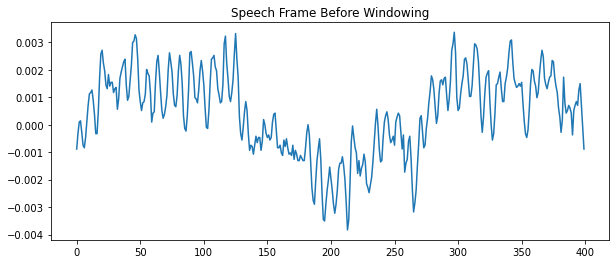

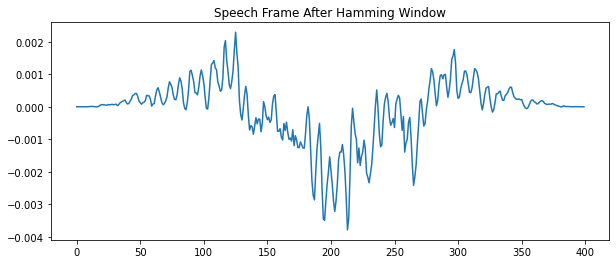

In [11]:
## STEP 7.5 - Visualize One Frame Before and After Windowing
frame_index = 10
plt.figure(figsize=(10,4))
plt.plot(
frames[frame_index].numpy()
)
plt.title("Speech Frame Before Windowing")
plt.show()
plt.figure(figsize=(10,4))
plt.plot(
windowed_frames[frame_index].numpy()
)
plt.title("Speech Frame After Hamming Window")
plt.show()

In [12]:
## STEP 8.1 - Extract MFCC Features from Windowed Frames
import torchaudio.transforms as transforms
# MFCC Feature Extractor
mfcc_transform = transforms.MFCC(
sample_rate=sample_rate,
n_mfcc=13,
melkwargs={
"n_fft": 400,
"hop_length": 160,
"n_mels": 40
}
)
mfcc_features = mfcc_transform(waveform)
print("MFCC Feature Shape:")
print(mfcc_features.shape)

MFCC Feature Shape:
torch.Size([1, 13, 1044])


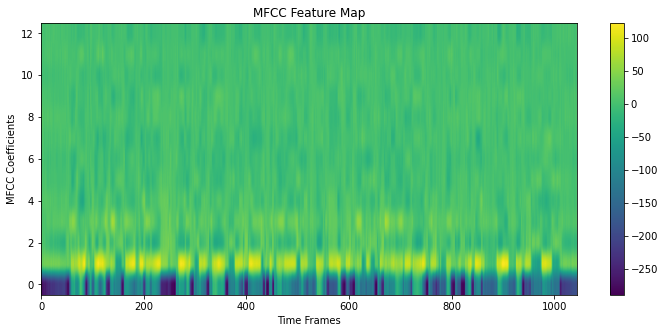

In [13]:
## STEP 8.2 Visualize MFCC
plt.figure(figsize=(12,5))
plt.imshow(
mfcc_features.squeeze().numpy(),
aspect="auto",
origin="lower"
)
plt.title("MFCC Feature Map")
plt.xlabel("Time Frames")
plt.ylabel("MFCC Coefficients")
plt.colorbar()
plt.show()

In [14]:
## STEP 8.3 - Extract Log-Mel Spectrogram from Windowed Frames
mel_transform = transforms.MelSpectrogram(
sample_rate=sample_rate,
n_fft=400,
hop_length=160,
n_mels=64
)
mel_spectrogram = mel_transform(waveform)
# Convert to log scale
log_mel = torch.log(
mel_spectrogram + 1e-9
)
print("Log Mel Shape:")
print(log_mel.shape)

Log Mel Shape:
torch.Size([1, 64, 1044])


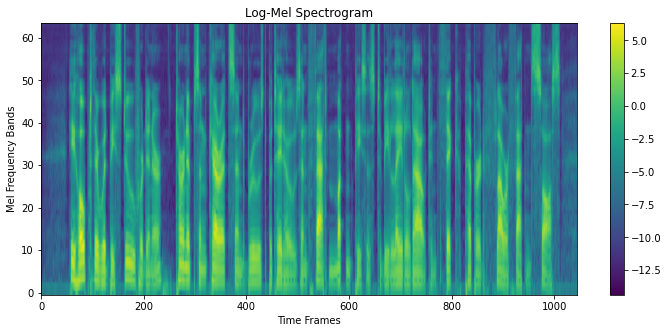

In [15]:
## STEP 8.4 Visualize Log-Mel Spectrogram
plt.figure(figsize=(12,5))
plt.imshow(
log_mel.squeeze().numpy(),
aspect="auto",
origin="lower"
)
plt.title("Log-Mel Spectrogram")
plt.xlabel("Time Frames")
plt.ylabel("Mel Frequency Bands")
plt.colorbar()
plt.show()

In [16]:
## STEP 8.5 Prepare Features for Neural Network
## DNN/LSTM expects : (batch_size, time_steps, feature_dim)
## Currently: (channel, features, time)
input_features = mfcc_features.squeeze().transpose(0,1)
print("DNN Input Shape:")
print(input_features.shape)

DNN Input Shape:
torch.Size([1044, 13])


In [18]:
## STEP 9.1 Prepare Training Data
## For Assignment, we create acoustic state lables
## In real ASR, these states come from phoneme alignment. Here we simulate HMM State for demostrating hybrid ASR.
# Number of acoustic states
num_states = 20
# MFCC sequence length
sequence_length = input_features.shape[0]
# Generate sample acoustic state labels
state_labels = torch.randint(
low=0,
high=num_states,
size=(sequence_length,)
)
print("Input Feature Shape:")
print(input_features.shape)
print("State Labels Shape:")
print(state_labels.shape)

Input Feature Shape:
torch.Size([1044, 13])
State Labels Shape:
torch.Size([1044])


In [22]:
## STEP 9.2 Define LSTM Acoustic Model
import torch.nn as nn
class AcousticModel(nn.Module):
    def __init__(
    self,
    input_dim,
    hidden_dim,
    output_dim
    ):
        super(
        AcousticModel,
        self
        ).__init__()
        self.lstm = nn.LSTM(
        input_dim,
        hidden_dim,
        batch_first=True
        )
        self.fc = nn.Linear(
        hidden_dim,
        output_dim
        )
    def forward(
    self,
    x
    ):
        lstm_output, _ = self.lstm(x)
        output = self.fc(
        lstm_output
        )
        return output

In [23]:
## STEP 9.3 Initialize Model
input_dim = 13
hidden_dim = 64
model = AcousticModel(
input_dim=input_dim,
hidden_dim=hidden_dim,
output_dim=num_states
)
print(model)

AcousticModel(
  (lstm): LSTM(13, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=20, bias=True)
)


In [24]:
## STEP 9.4 Prpare Tensor Shape
## LSTM expects (batch_size, time_steps, feature_dim)
X = input_features.unsqueeze(0)
y = state_labels.unsqueeze(0)
print("X Shape:", X.shape)
print("Y Shape:", y.shape)

X Shape: torch.Size([1, 1044, 13])
Y Shape: torch.Size([1, 1044])


In [26]:
## STEP 9.5 Train Acoustic Model
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
model.parameters(),
lr=0.001
)
epochs = 20
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(X)
    loss = criterion(
    outputs.reshape(-1, num_states),
    y.reshape(-1)
    )
    loss.backward()
    optimizer.step()
    print(
    f"Epoch {epoch+1}/{epochs}, Loss={loss.item():.4f}"
    )

Epoch 1/20, Loss=3.0314
Epoch 2/20, Loss=3.0206
Epoch 3/20, Loss=3.0122
Epoch 4/20, Loss=3.0042
Epoch 5/20, Loss=2.9973
Epoch 6/20, Loss=2.9913
Epoch 7/20, Loss=2.9852
Epoch 8/20, Loss=2.9798
Epoch 9/20, Loss=2.9748
Epoch 10/20, Loss=2.9703
Epoch 11/20, Loss=2.9662
Epoch 12/20, Loss=2.9623
Epoch 13/20, Loss=2.9584
Epoch 14/20, Loss=2.9545
Epoch 15/20, Loss=2.9508
Epoch 16/20, Loss=2.9473
Epoch 17/20, Loss=2.9441
Epoch 18/20, Loss=2.9410
Epoch 19/20, Loss=2.9381
Epoch 20/20, Loss=2.9353


In [28]:
## STEP 9.6 Generate DNN State Probabilities
with torch.no_grad():
    dnn_output = model(X)
    state_probabilities = torch.softmax(
    dnn_output,
    dim=-1
    )
    print(
    "State Probability Shape:",
    state_probabilities.shape
    )

State Probability Shape: torch.Size([1, 1044, 20])


In [30]:
## STEP 10.1 - Convert DNN Output to HMM Emission Probabilities
# Remove batch dimension
emission_probabilities = state_probabilities.squeeze(0)
print(
"Emission Probability Shape:",
emission_probabilities.shape
)



Emission Probability Shape: torch.Size([1044, 20])


In [32]:
## STEP 10.2 - Create HMM Transition Matrix
transition_matrix = torch.zeros(
num_states,
num_states
)
for i in range(num_states):
    # stay in same state
    transition_matrix[i][i] = 0.6
    # move to next state
    if i + 1 < num_states:
        transition_matrix[i][i+1] = 0.4
    else:
        transition_matrix[i][i] = 1.0
print(
transition_matrix
)

tensor([[0.6000, 0.4000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000],
        [0.0000, 0.6000, 0.4000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000],
        [0.0000, 0.0000, 0.6000, 0.4000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.6000, 0.4000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.6000, 0.4000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.6000, 0.4

In [33]:
## STEP 10.3 Implement Viterbi Algorithm
def viterbi_decode(
emissions,
transitions
):
    time_steps, states = emissions.shape
    dp = torch.zeros(
    time_steps,
    states
    )
    backpointer = torch.zeros(
    time_steps,
    states,
    dtype=torch.long
    )
    dp[0] = torch.log(
    emissions[0] + 1e-10
    )
    for t in range(
    1,
    time_steps
    ):
        for s in range(states):
            probabilities = (
            dp[t-1]
            +
            torch.log(
            transitions[:,s] + 1e-10
            )
            )
            best_previous = torch.argmax(
            probabilities
            )
            dp[t][s] = (
            probabilities[best_previous]
            +
            torch.log(
            emissions[t][s] + 1e-10
            )
            )
            backpointer[t][s] = best_previous
    # Backtracking
    best_path = []
    last_state = torch.argmax(
    dp[-1]
    )
    best_path.append(
    last_state.item()
    )
    for t in range(
    time_steps-1,
    0,
    -1
    ):
        last_state = backpointer[t][last_state]
        best_path.append(
            last_state.item()
        )
    best_path.reverse()
    return best_path

In [34]:
## STEP 10.4 - Decode Speech States
decoded_states = viterbi_decode(
    emission_probabilities,
    transition_matrix
)
print(
    "Decoded Sequence Length:",
    len(decoded_states)
)
print(
    decoded_states[:50]
)

Decoded Sequence Length: 1044
[19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19]


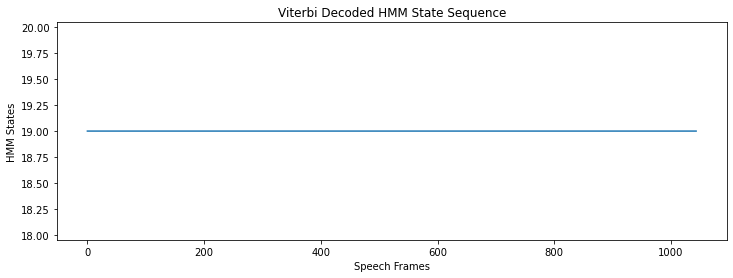

In [35]:
## STEP 10.5 Visualize HMM State Path
plt.figure(figsize=(12,4))
plt.plot(
decoded_states
)
plt.title(
"Viterbi Decoded HMM State Sequence"
)
plt.xlabel(
"Speech Frames"
)
plt.ylabel(
"HMM States"
)
plt.show()

In [36]:
## STEP 11.1 - Create State-to-Word Mapping
## In Real ASR: HMM States → Phonemes → Words
## For Assignment, we map decoded states into vocabulary tokens
# Create simple vocabulary from transcript
words = transcript.split()
print("Original Words:")
print(words)
# Map states to available words
state_word_map = {}
for i in range(num_states):
    state_word_map[i] = words[
    i % len(words)
    ]
print(state_word_map)

Original Words:
['HE', 'HOPED', 'THERE', 'WOULD', 'BE', 'STEW', 'FOR', 'DINNER', 'TURNIPS', 'AND', 'CARROTS', 'AND', 'BRUISED', 'POTATOES', 'AND', 'FAT', 'MUTTON', 'PIECES', 'TO', 'BE', 'LADLED', 'OUT', 'IN', 'THICK', 'PEPPERED', 'FLOUR', 'FATTENED', 'SAUCE']
{0: 'HE', 1: 'HOPED', 2: 'THERE', 3: 'WOULD', 4: 'BE', 5: 'STEW', 6: 'FOR', 7: 'DINNER', 8: 'TURNIPS', 9: 'AND', 10: 'CARROTS', 11: 'AND', 12: 'BRUISED', 13: 'POTATOES', 14: 'AND', 15: 'FAT', 16: 'MUTTON', 17: 'PIECES', 18: 'TO', 19: 'BE'}


In [38]:
## STEP 11.2 - Convert HMM States to Text
recognized_words = []
previous_state = None
for state in decoded_states:
    # avoid repeated states
    if state != previous_state:
        recognized_words.append(
    state_word_map[state]
    )
    previous_state = state
recognized_text = " ".join(
recognized_words
)
print("Actual Transcript:")
print(transcript)
print("\nRecognized Text:")
print(recognized_text)

Actual Transcript:
HE HOPED THERE WOULD BE STEW FOR DINNER TURNIPS AND CARROTS AND BRUISED POTATOES AND FAT MUTTON PIECES TO BE LADLED OUT IN THICK PEPPERED FLOUR FATTENED SAUCE

Recognized Text:
BE


In [40]:
## STEP 11.3 - Calculate Word Error Rate (WER)
from jiwer import wer
error_rate = wer(
transcript,
recognized_text
)
print(
"Word Error Rate:",
error_rate
)

Word Error Rate: 0.9642857142857143


In [41]:
## STEP 11.4 - Calculate Accuracy
recognition_accuracy = (
1 - error_rate
) * 100
print(
f"Recognition Accuracy: {recognition_accuracy:.2f}%"
)

Recognition Accuracy: 3.57%


In [42]:
## STEP 11.5 - Store Results Table
import pandas as pd
results = pd.DataFrame(
{
"Metric": [
"WER",
"Recognition Accuracy"
],
"Value": [
error_rate,
recognition_accuracy
]
}
)
results

,Metric,Value
0,WER,0.964286
1,Recognition Accuracy,3.571429
